In [1]:
from cartoblobpy.graph import Graph

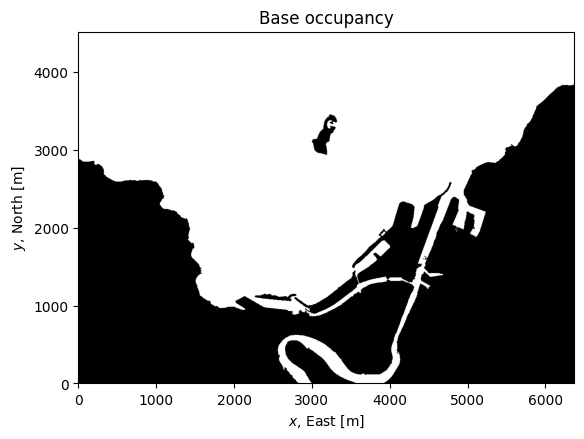

In [2]:
g = Graph()
# g.coordinate_frame = "NED"  # or "ENU"
g.load_from_yaml("./map.yaml")
g.inflate_obstacles(radius=0.0, use_world_units=True)  # 5 meters
ax = g.plot(cmap="gray")

In [3]:
# Get value from traffic layer at a specific point (world coordinates [x, y])
point = (2500, 2500)
row, col = g.world_to_grid(point).astype(int)

depth = g.layers["depth"]
if depth is None:
    raise ValueError("Layer 'traffic' exists but has no data file.")

h, w = depth.shape
if not (0 <= row < h and 0 <= col < w):
    raise IndexError(f"Point {point} maps to grid ({row}, {col}) outside layer bounds {(h, w)}")

value = float(depth[row, col])
print(f"depth[{row}, {col}] = {value}")

depth[497, 497] = 100.0


depth shape: (900, 1269)
depth min/max: 0.000 / 350.000
depth mean: 44.586
unique values (sample): [  0.   2.   5.  10.  20.  50. 100. 200. 350.]
sample point: [3184.088748 2259.9999  ]
traffic[450, 634] = 50.000


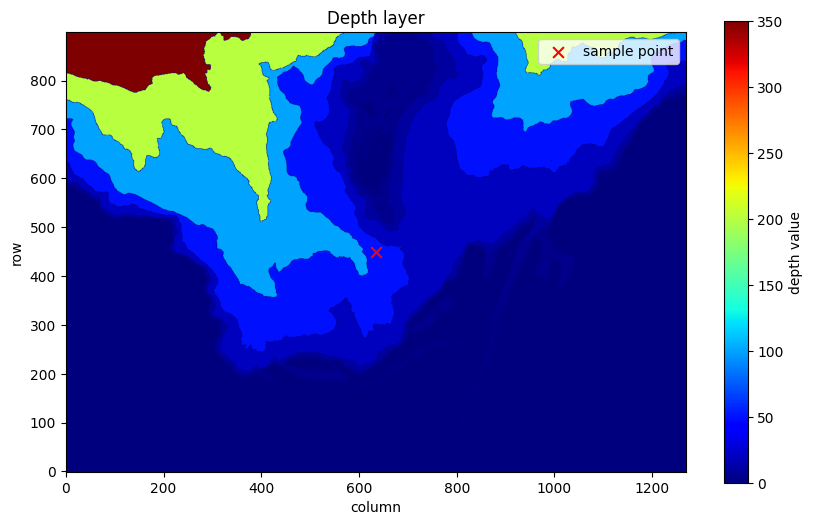

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Traffic layer demo
depth = g.layers["depth"]
if depth is None:
    raise ValueError("Layer 'depth' exists but has no data file.")

print(f"depth shape: {depth.shape}")
print(f"depth min/max: {depth.min():.3f} / {depth.max():.3f}")
print(f"depth mean: {depth.mean():.3f}")
print(f"unique values (sample): {np.unique(depth)[:10]}")

# Sample a point in world coordinates [x, y]
point = g.grid_to_world((depth.shape[0] // 2, depth.shape[1] // 2))
row, col = g.world_to_grid(point).astype(int)

if not (0 <= row < depth.shape[0] and 0 <= col < depth.shape[1]):
    raise IndexError(f"Point {point} maps to grid ({row}, {col}) outside layer bounds {depth.shape}")

value = float(depth[row, col])
print(f"sample point: {point}")
print(f"traffic[{row}, {col}] = {value:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(depth, cmap="jet", origin="lower")
ax.scatter([col], [row], c="red", s=60, marker="x", label="sample point")
ax.set_title("Depth layer")
ax.set_xlabel("column")
ax.set_ylabel("row")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label="depth value")
plt.show()